# Angular Power Spectrum Comparison

This notebook compares angular power spectra from different observational configurations to assess sensitivity to dark photon signals. We compare:
- Real and mock Planck data
- SKA configurations with different point source thresholds
- Planck with modified beam parameters

The goal is to evaluate how different instrumental setups perform for constraining dark photon-photon coupling through both auto-correlations and cross-correlations with galaxy catalogs.

In [1]:
import os, sys
import pickle

import matplotlib_inline
sys.path.append("../")

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
from matplotlib import gridspec
from matplotlib import ticker
from matplotlib.lines import Line2D

from tqdm import tqdm

from scipy.interpolate import interp1d
import numpy as np
import pymaster as nmt

matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

%matplotlib inline
%load_ext autoreload
%autoreload 2
# Load plot settings
import healpy as hp
from plot_params import params
pylab.rcParams.update(params)

cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

## Load Power Spectra

Load the binned angular power spectra for different observational configurations. All spectra use binning with 10 multipoles per bin. We also load the predicted dark photon signal power spectrum.

In [2]:
# load power spectra
binning = nmt.NmtBin.from_nside_linear(2048, 10)

mccarthy_Cls = np.load("data/real_Planck_auto_Cls_binning10.npy")
mock_planck_Cls = np.load("data/mock_Planck_auto_Cls_binning10.npy")
small_beam = np.load("data/Planck_small_beam_auto_Cls_binning10.npy")
fiducial_SKA = np.load("data/fiducial_SKA_auto_Cls_binning10.npy")
SKA_100mJy = np.load("data/SKA_100mJy_auto_Cls_binning10.npy")

signal = np.load("data/Cl_PP_mA5.623e-13.npy")
signal_ls = np.load("data/ls.npy")

## Load Covariance Matrices

Load the covariance matrices corresponding to each power spectrum. These are needed to properly compute error bars and perform likelihood analyses.

In [3]:
mccarthy_covs = np.load("data/real_Planck_covariance_clean_PP_binning10_K22.npy")
mock_planck_covs = np.load("data/mock_Planck_covariance_clean_PP_binning10_K22.npy")
small_beam_covs = np.load("data/Planck_small_beam_covariance_clean_PP_binning10_K22.npy")
fiducial_SKA_covs = np.load("data/fiducial_SKA_covariance_clean_PP_binning10_K22.npy")
SKA_100mJy_covs = np.load("data/SKA_100mJy_covariance_clean_PP_binning10_K22.npy")

## Normalization Factors

Define normalization factors to convert between different temperature units and reference frequencies. The McCarthy prefactor converts from the 353 GHz reference used in their analysis, while our prefactor normalizes to 410 MHz for radio observations.

In [4]:
# Normalization factor used in McCarthy et al. for 353 GHz reference
TCMB_eV = 0.000235264 
x = 2 * np.pi * 0.000232349 / TCMB_eV  # 353 GHz in eV units
mc_prefac = TCMB_eV * x**2 / (1 - np.exp(-x))

In [5]:
# Our normalization at radio frequency (410 MHz converted to eV)
new_prefac = 2 * np.pi * 410e6 * 6.58212e-16

In [6]:
# load power spectra
cross_binning = nmt.NmtBin.from_nside_linear(2048, 150)

SKA_cross = np.load("data/fiducial_SKA_cross_Pg_Cls_binning150_K22.npy")
SKA_cross_covs = np.load('data/fiducial_SKA_covariance_clean_gP_binning150_K22.npy')

cross_signal = np.load("data/Cl_gP_mA5.623e-13_modelK22.npy")

## Load Cross-Correlation Data

Load the cross-correlation power spectra between 21cm maps and galaxy catalogs, along with covariance matrices. Cross-correlations use larger bins (150 multipoles).

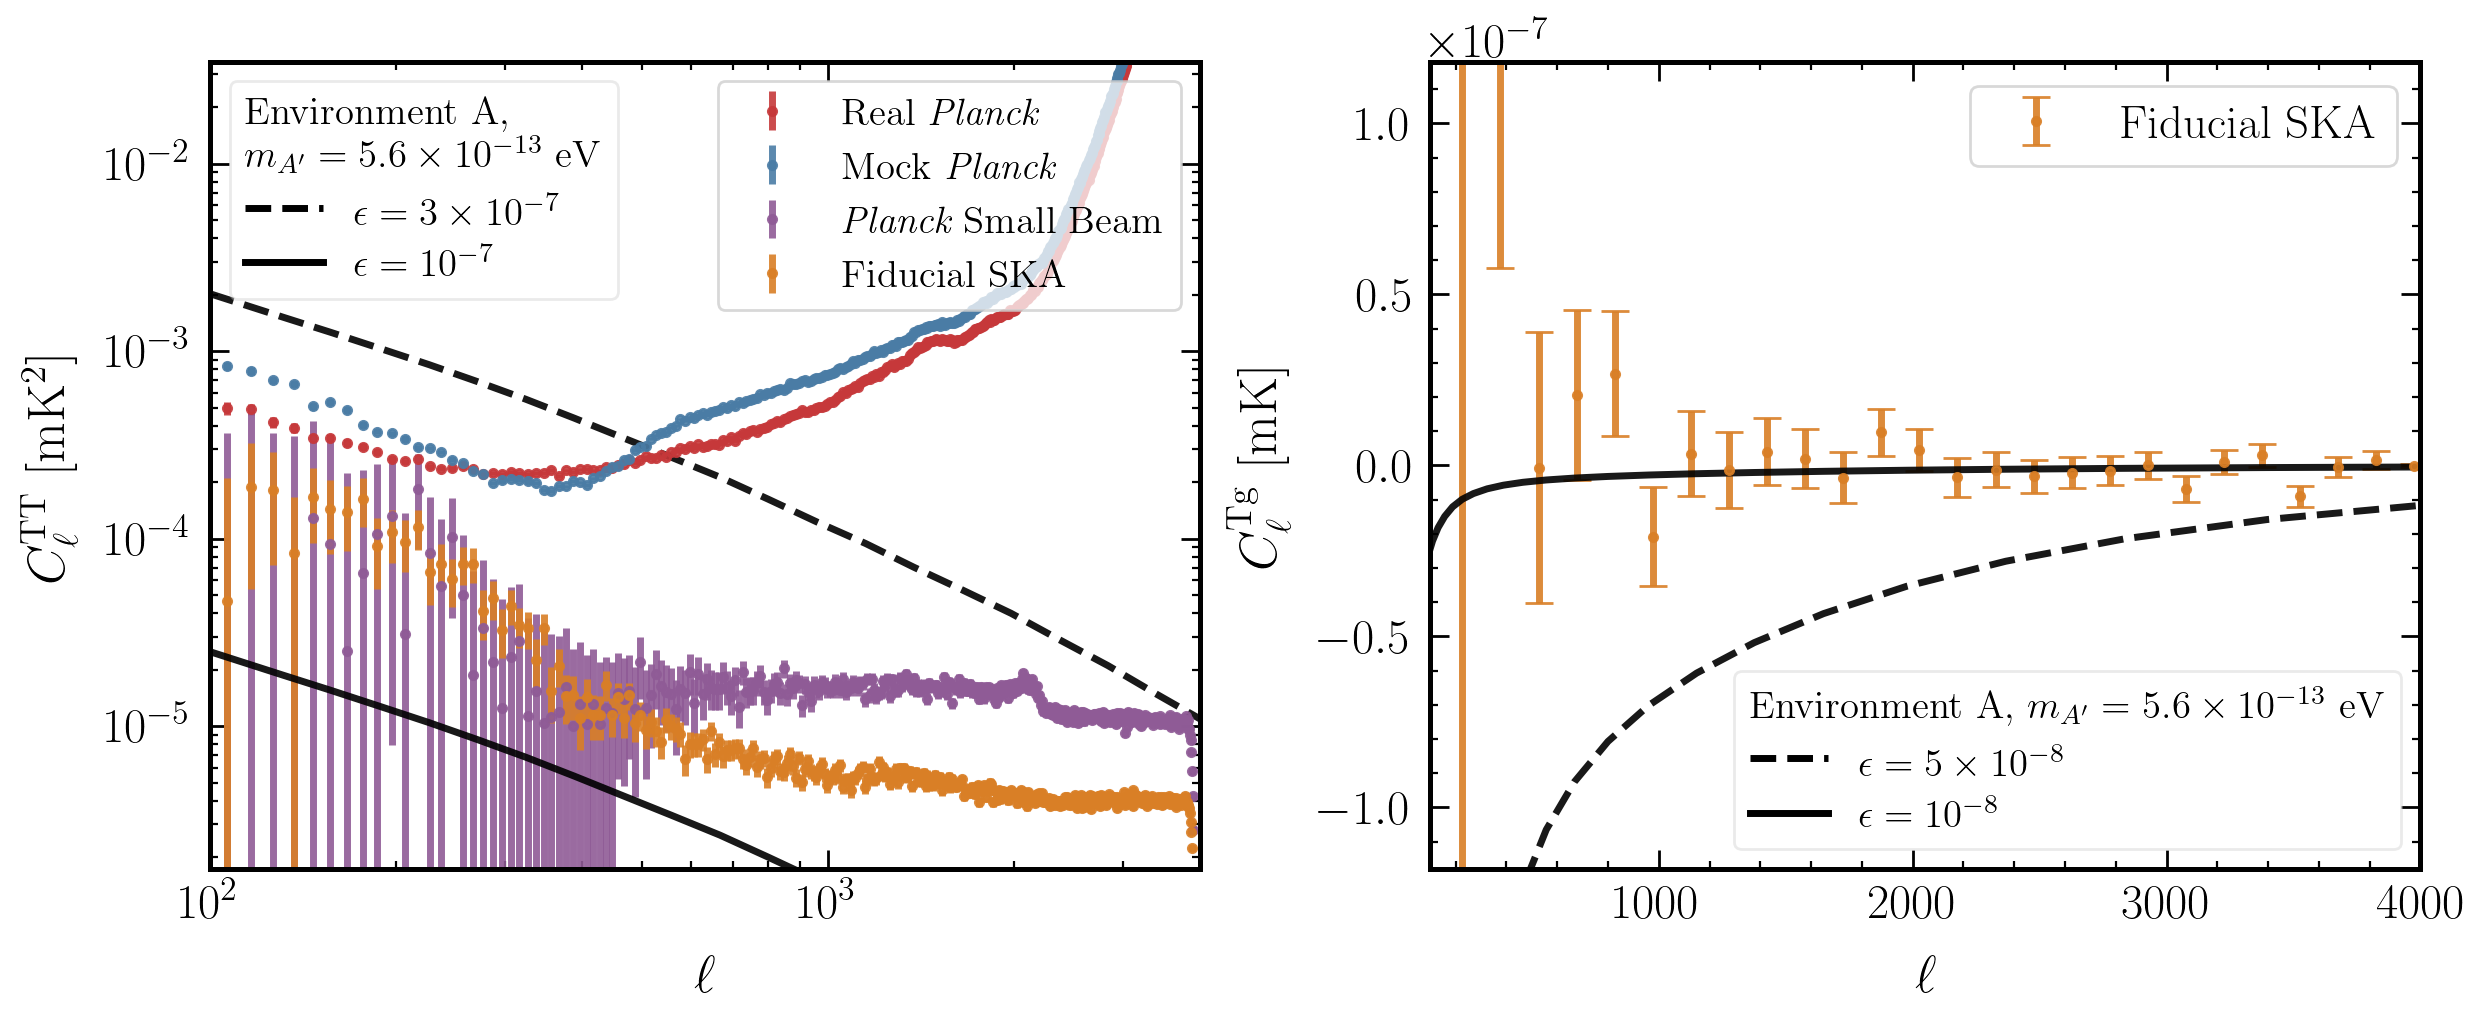

In [32]:
from matplotlib.lines import lineStyles

fig, ax = plt.subplots(1, 2, figsize=(2*6.153846153846153, 5.0), constrained_layout=True)


ax[0].errorbar(
    binning.get_effective_ells(),
    mccarthy_Cls * mc_prefac**2 / new_prefac**2 ,
    yerr=mc_prefac**2 * np.sqrt(np.diag(mccarthy_covs)) / new_prefac**2,
    capsize=0,
    linestyle=" ",
    marker=".",
    label=r"Real \textit{Planck}",
    color=cols_default[0],
)

ax[0].errorbar(
    binning.get_effective_ells(),
    mock_planck_Cls * mc_prefac**2 / new_prefac**2,
    yerr= mc_prefac**2 * np.sqrt(np.diag(mock_planck_covs)) / new_prefac**2,
    capsize=0,
    linestyle=" ",
    marker=".",
    label=r"Mock \textit{Planck}",
    color=cols_default[1],
)

ax[0].errorbar(
    binning.get_effective_ells(),
    small_beam / new_prefac**2,
    yerr=np.sqrt(np.diag(small_beam_covs)) / new_prefac**2,
    capsize=0,
    linestyle=" ",
    marker=".",
    label=r"$\textit{Planck}$ Small Beam",
    color=cols_default[3],
)

ax[0].errorbar(
    binning.get_effective_ells(),
    fiducial_SKA / new_prefac**2,
    yerr=np.sqrt(np.diag(fiducial_SKA_covs)) / new_prefac**2,
    capsize=0,
    linestyle=" ",
    marker=".",
    label="Fiducial SKA",
    color=cols_default[4],
)
ax[0].plot(
    signal_ls,
    (2.73e3) ** 2 * (1e-7)**4 * signal / new_prefac**2,
    linestyle="-",
    color="k",
    # label="Theoretical Signal",
)
ax[0].plot(
    signal_ls,
    (2.73e3) ** 2 * (3e-7)**4 * signal / new_prefac**2,
    linestyle="--",
    color="k",
    # label="Theoretical Signal",
)
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlim(100, 4000)
ax[0].set_ylim(0.5e-17 / new_prefac**2, 1e-13 / new_prefac**2)

small_eps_line = Line2D([0,1],[0,1],linestyle='-', color='k')
big_eps_line = Line2D([0,1],[0,1],linestyle='--', color='k')
legend2 = ax[0].legend([big_eps_line,small_eps_line], [r"$\epsilon=3\times10^{-7}$",r"$\epsilon=10^{-7}$"], 
                     fontsize=14, loc="upper left", frameon=True, 
                     title="Environment A,\n" + r"$m_{A'}=5.6\times 10^{-13}$ eV",
                     title_fontsize=14)

# legend2.set_title("Predicted Signal,\n" + r"$m_{A'}=5.6\times 10^{-13}$ eV")
ax[0].add_artist(legend2)
legend2._legend_box.align = 'left'
    
legend1 = ax[0].legend(fontsize=14, frameon=True, loc="upper right", framealpha=0.75) # loc='center left', bbox_to_anchor=(1, 0.5))

ax[0].set_xlabel(r"$\ell$")
ax[0].set_ylabel(r"$C^{\rm TT}_\ell$ [mK$^2$]")


ax[1].errorbar(
    cross_binning.get_effective_ells(),
    SKA_cross / new_prefac,
    yerr=np.sqrt(np.diag(SKA_cross_covs)) / new_prefac,
    # capsize=0,
    linestyle=" ",
    marker=".",
    label="Fiducial SKA",
    color=cols_default[4],
)

ax[1].plot(
    signal_ls,
    -(2.73e3) * (5e-8)**2 * cross_signal /new_prefac,
    linestyle="--",
    color="k",
    # label="Theoretical Signal",
)

ax[1].plot(
    signal_ls,
    -(2.73e3) * (1e-8)**2 * cross_signal /new_prefac,
    linestyle="-",
    color="k",
    # label="Theoretical Signal",
)

legend2 = ax[1].legend([big_eps_line, small_eps_line], [r"$\epsilon=5\times 10^{-8}$", r"$\epsilon=10^{-8}$"], 
                     loc="lower right", frameon=True, 
                     title=r"Environment A, $m_{A'}=5.6\times 10^{-13}$ eV", 
                     title_fontsize=14, fontsize=14)

ax[1].add_artist(legend2)
legend2._legend_box.align = 'left'

legend1 = ax[1].legend(frameon=True, loc="upper right", framealpha=0.75) # loc='center left', bbox_to_anchor=(1, 0.5))

# ax[1].set_xscale("log")
ax[1].set_xlim(100, 4000)
ax[1].set_ylim(-0.2e-12/new_prefac,  0.2e-12/new_prefac)

ax[1].set_xlabel(r"$\ell$")
ax[1].set_ylabel(r"$C^{\rm Tg}_\ell$ [mK]")
ax[1].ticklabel_format(axis='y', style='sci', scilimits=(-4, 4))
plt.savefig("plots/Cl_comparsion.pdf", bbox_inches="tight")


## Comparison Plot: Auto and Cross Power Spectra

Create a two-panel figure comparing:
- Left panel: Auto-correlation power spectra from different configurations with predicted signals
- Right panel: Cross-correlation between 21cm and galaxies with predicted signal

All power spectra are normalized to radio frequencies (410 MHz) for consistent comparison. Predicted signals are shown for two different coupling strengths.

In [11]:
fiducial_SKA_150 = np.load("data/fiducial_SKA_auto_Cls_binning150.npy")
fiducial_SKA_covs_150 = np.load("data/fiducial_SKA_covariance_clean_PP_binning150_K22.npy")
binning_150 = nmt.NmtBin.from_nside_linear(2048, 150)


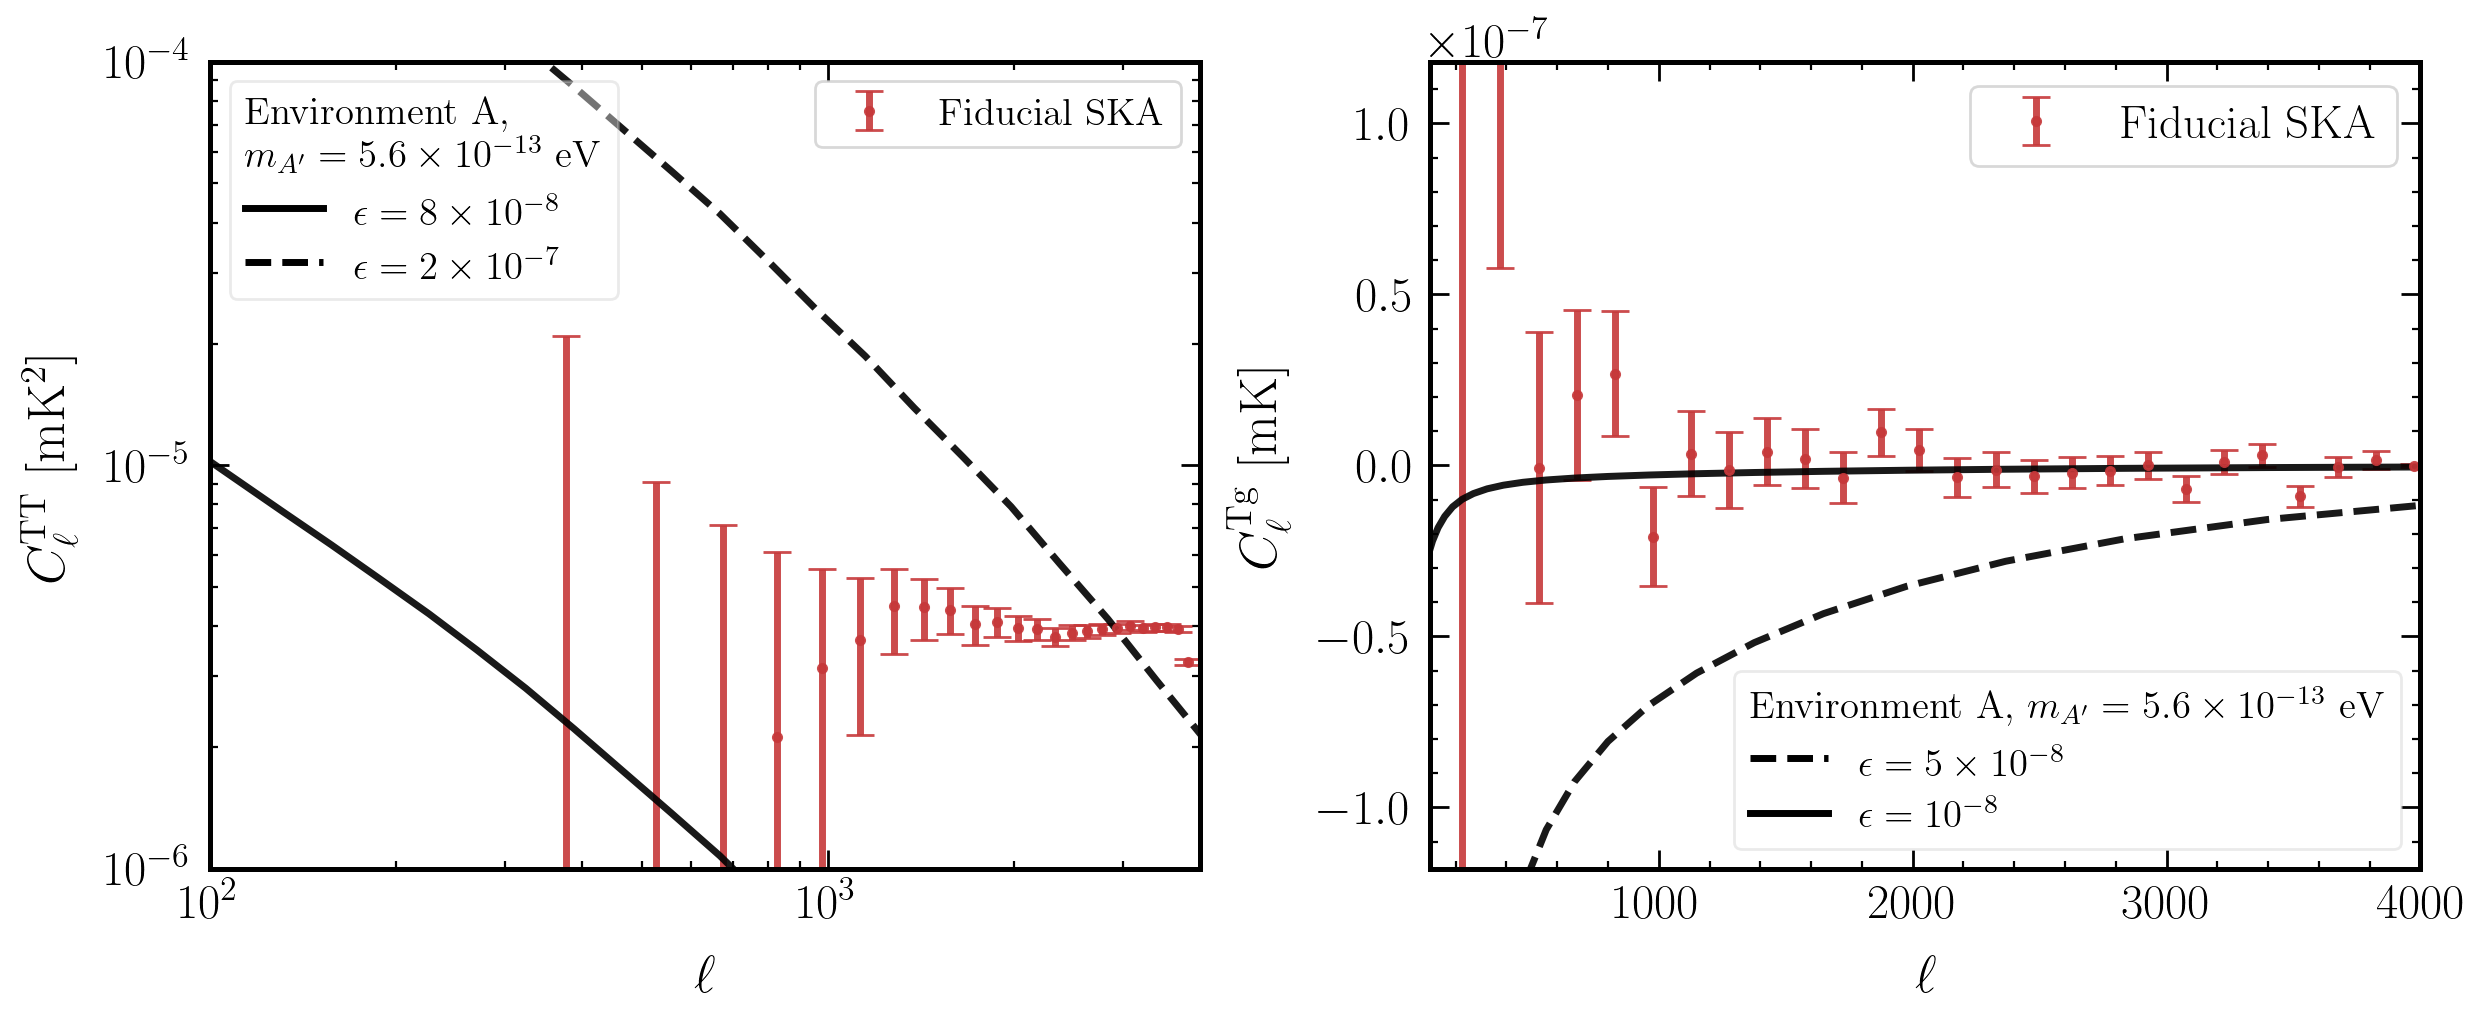

In [31]:
from matplotlib.lines import lineStyles

fig, ax = plt.subplots(1, 2, figsize=(2*6.153846153846153, 5.0), constrained_layout=True)

ax[0].errorbar(
    binning_150.get_effective_ells(),
    fiducial_SKA_150 / new_prefac**2,
    yerr=np.sqrt(np.diag(fiducial_SKA_covs_150)) / new_prefac**2,
    # capsize=0,
    linestyle=" ",
    marker=".",
    label="Fiducial SKA",
    color=cols_default[0],
)
ax[0].plot(
    signal_ls,
    (2.73e3) ** 2 * (0.8e-7)**4 * signal / new_prefac**2,
    linestyle="-",
    color="k",
    # label="Theoretical Signal",
)
ax[0].plot(
    signal_ls,
    (2.73e3) ** 2 * (2e-7)**4 * signal / new_prefac**2,
    linestyle="--",
    color="k",
    # label="Theoretical Signal",
)
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlim(100, 4000)
ax[0].set_ylim(1e-6, 1e-4)

small_eps_line = Line2D([0,1],[0,1],linestyle='-', color='k')
big_eps_line = Line2D([0,1],[0,1],linestyle='--', color='k')
legend2 = ax[0].legend([small_eps_line, big_eps_line], [r"$\epsilon=8\times10^{-8}$", r"$\epsilon=2\times10^{-7}$"], 
                     fontsize=14, loc="upper left", frameon=True, 
                     title="Environment A,\n" + r"$m_{A'}=5.6\times 10^{-13}$ eV",
                     title_fontsize=14)

# legend2.set_title("Predicted Signal,\n" + r"$m_{A'}=5.6\times 10^{-13}$ eV")
ax[0].add_artist(legend2)
legend2._legend_box.align = 'left'
    
legend1 = ax[0].legend(fontsize=14, frameon=True, loc="upper right", framealpha=0.75) # loc='center left', bbox_to_anchor=(1, 0.5))

ax[0].set_xlabel(r"$\ell$")
ax[0].set_ylabel(r"$C^{\rm TT}_\ell$ [mK$^2$]")


ax[1].errorbar(
    cross_binning.get_effective_ells(),
    SKA_cross / new_prefac,
    yerr=np.sqrt(np.diag(SKA_cross_covs)) / new_prefac,
    # capsize=0,
    linestyle=" ",
    marker=".",
    label="Fiducial SKA",
    color=cols_default[0],
)

ax[1].plot(
    signal_ls,
    -(2.73e3) * (5e-8)**2 * cross_signal /new_prefac,
    linestyle="--",
    color="k",
    # label="Theoretical Signal",
)

ax[1].plot(
    signal_ls,
    -(2.73e3) * (1e-8)**2 * cross_signal /new_prefac,
    linestyle="-",
    color="k",
    # label="Theoretical Signal",
)

legend2 = ax[1].legend([big_eps_line, small_eps_line], [r"$\epsilon=5\times 10^{-8}$", r"$\epsilon=10^{-8}$"], 
                     loc="lower right", frameon=True, 
                     title=r"Environment A, $m_{A'}=5.6\times 10^{-13}$ eV", 
                     title_fontsize=14, fontsize=14)

ax[1].add_artist(legend2)
legend2._legend_box.align = 'left'

legend1 = ax[1].legend(frameon=True, loc="upper right", framealpha=0.75) # loc='center left', bbox_to_anchor=(1, 0.5))

# ax[1].set_xscale("log")
ax[1].set_xlim(100, 4000)
ax[1].set_ylim(-0.2e-12/new_prefac,  0.2e-12/new_prefac)

ax[1].set_xlabel(r"$\ell$")
ax[1].set_ylabel(r"$C^{\rm Tg}_\ell$ [mK]")
ax[1].ticklabel_format(axis='y', style='sci', scilimits=(-4, 4))
plt.savefig("plots/prd_Cl_comparsion.pdf", bbox_inches="tight")
